In [1]:
# ============================================
# TASK 3: END-TO-END DATA SCIENCE PROJECT
# HOUSE PRICE PREDICTION
# ============================================

# Step 1: Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import joblib

In [2]:
# Step 2: Load California Housing dataset

housing = fetch_california_housing()

# Convert into DataFrame

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Add target column

df['Price'] = housing.target

print("Dataset Loaded Successfully!\n")

print(df.head())

print("\nDataset Shape:", df.shape)

Dataset Loaded Successfully!

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Dataset Shape: (20640, 9)


In [3]:
# Step 3: Dataset information

print("\nColumn Names:\n")
print(df.columns)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nStatistical Summary:\n")
print(df.describe())


Column Names:

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='object')

Missing Values:

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

Statistical Summary:

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       

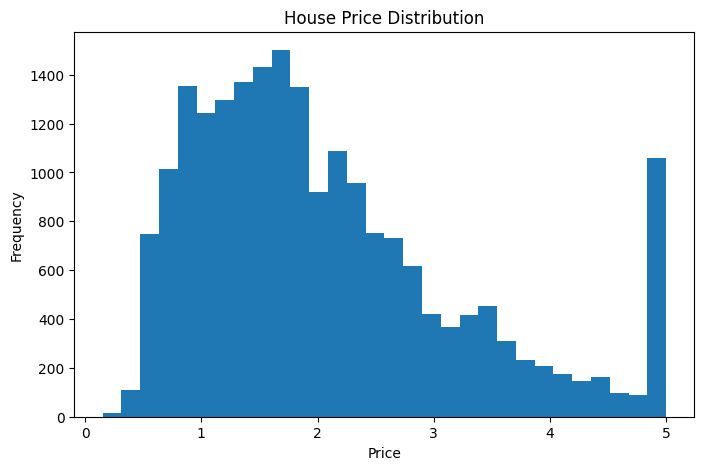

In [4]:
# Step 4: Plot target distribution

plt.figure(figsize=(8,5))

plt.hist(df['Price'], bins=30)

plt.title('House Price Distribution')

plt.xlabel('Price')

plt.ylabel('Frequency')

plt.show()

In [5]:
# Step 5: Separate features and target

X = df.drop('Price', axis=1)

y = df['Price']

print("Features Preview:\n")
print(X.head())

print("\nTarget Preview:\n")
print(y.head())

Features Preview:

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Target Preview:

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64


In [6]:
# Step 6: Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (16512, 8)
Testing Shape: (4128, 8)


In [7]:
# Step 7: Apply feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed!")

Feature Scaling Completed!


In [8]:
# Step 8: Train Linear Regression model

model = LinearRegression()

model.fit(
    X_train_scaled,
    y_train
)

print("Model Trained Successfully!")

Model Trained Successfully!


In [9]:
# Step 9: Predict house prices

y_pred = model.predict(X_test_scaled)

print("Predictions:\n")

print(y_pred[:10])

Predictions:

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [10]:
# Step 10: Evaluate model performance

mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print("Mean Squared Error:", mse)

print("R2 Score:", r2)

Mean Squared Error: 0.5558915986952444
R2 Score: 0.5757877060324508


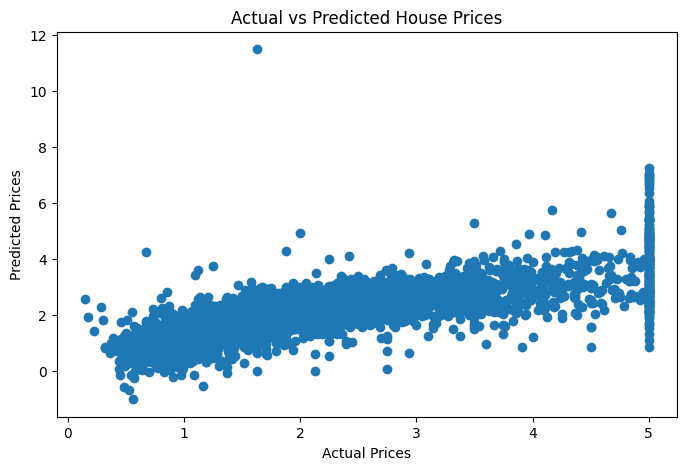

In [11]:
# Step 11 :Scatter plot of actual vs predicted values

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel('Actual Prices')

plt.ylabel('Predicted Prices')

plt.title('Actual vs Predicted House Prices')

plt.show()

In [12]:
# Step 12: Save trained model

joblib.dump(
    model,
    'house_price_model.pkl'
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [13]:
# Step 13: Save prediction graph

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel('Actual Prices')

plt.ylabel('Predicted Prices')

plt.title('Actual vs Predicted House Prices')

plt.savefig(
    'prediction_graph.png'
)

plt.close()

print("Graph Saved Successfully!")

Graph Saved Successfully!
